In [1]:
import os

# This forces TensorFlow to use the internal Keras 2 instead of the new Keras 3
os.environ["TF_USE_LEGACY_KERAS"] = "1"

# Transfer Learning with TensorFlow Part 3: Scaling up (🍔👁 Food Vision mini)

In the previous two notebooks, we've seen the power of transfer learning.

Now we know our smaller modelling experiments are working, it's time to step things up a notch with more data.

This is a common practice in machine learning and deep learning: get a model working on a small amount of data before scaling it up to a larger amount of data.

It's time to get closer to our Food Vision project coming to life. In this notebook we're going to scale up from using 10 classes of the Food101 data to using all of the classes in the Food101 dataset.

Our goal is to **beat the original [Food101 paper](https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/static/bossard_eccv14_food-101.pdf)'s results with 10% of data**.

![](https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/06-ml-serial-experimentation.png)
*Machine learning practitioners are serial experimenters. Start small, get a model working, see if your experiments work then gradually scale them up to where you want to go (we're going to be looking at scaling up throughout this notebook).*

## What we're going to cover

We're going to go through the follow with TensorFlow:

- Downloading and preparing 10% of the Food101 data (10% of training data)
- Training a feature extraction transfer learning model on 10% of the Food101 training data
- Fine-tuning our feature extraction model
- Saving and loaded our trained model
- Evaluating the performance of our Food Vision model trained on 10% of the training data
  - Finding our model's most wrong predictions
- Making predictions with our Food Vision model on custom images of food.

In [2]:
# Getting Helper Functions:

import wget

# Run commands below if the helper_functions.py file is not already downloded:
#url = 'https://raw.githubusercontent.com/Shailya777/Learning-Logs/refs/heads/main/Deep_Learning_with_Tensorflow/helper_functions.py'
#file = wget.download(url)

In [3]:
from helper_functions import create_tensorboard_callback
from helper_functions import plot_loss_curves
from helper_functions import unzip_data
from helper_functions import compare_historys
from helper_functions import walk_through_dir

## 101 Food Classes: Working with less data

So far we've confirmed the transfer learning model's we've been using work pretty well with the 10 Food Classes dataset. Now it's time to step it up and see how they go with the full 101 Food Classes.

In the original [Food101](https://www.kaggle.com/dansbecker/food-101) dataset there's 1000 images per class (750 of each class in the training set and 250 of each class in the test set), totalling 101,000 imags.

We could start modelling straight away on this large dataset but in the spirit of continually experimenting, we're going to see how our previously working model's go with 10% of the training data.

This means for each of the 101 food classes we'll be building a model on 75 training images and evaluating it on 250 test images.

In [4]:
# Getting Data:
url = 'https://storage.googleapis.com/ztm_tf_course/food_vision/101_food_classes_10_percent.zip'
file = wget.download(url)

100% [....................................................................] 1625420029 / 1625420029

In [5]:
# Unzipping The Data:
unzip_data('101_food_classes_10_percent.zip')

In [6]:
# Walking Through Directory of Data:
walk_through_dir('101_food_classes_10_percent')

There are 2 directories and 0 images in '101_food_classes_10_percent'.
There are 101 directories and 0 images in '101_food_classes_10_percent/train'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/cheese_plate'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/pizza'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/beignets'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/donuts'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/seaweed_salad'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/steak'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/french_fries'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/tacos'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/poutine'.
There are 0 directories and 75 images in '101_food_classes_10_perc

In [7]:
# Setting up Training and Test Data Directory Paths:

train_dir = '101_food_classes_10_percent/train/'
test_dir = '101_food_classes_10_percent/test/'

In [9]:
# Importing Necessary Libraries:
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, RandomHeight, RandomWidth, Rescaling
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.models import Sequential

import warnings
warnings.filterwarnings('ignore')

In [11]:
# Setting up Data Loaders for the Model:

IMG_SHAPE = (224,224)

train_data_all_10_percent = tf.keras.preprocessing.image_dataset_from_directory(directory= train_dir,
                                                                               image_size= IMG_SHAPE,
                                                                               label_mode= 'categorical',
                                                                               batch_size= 32)

test_data = tf.keras.preprocessing.image_dataset_from_directory(directory= test_dir,
                                                               image_size= IMG_SHAPE,
                                                               label_mode= 'categorical',
                                                               batch_size= 32)

Found 7575 files belonging to 101 classes.
Found 25250 files belonging to 101 classes.


## Train a big model with transfer learning on 10% of 101 food classes

Our food image data has been imported into TensorFlow, time to model it.

To keep our experiments swift, we're going to start by using feature extraction transfer learning with a pre-trained model for a few epochs and then fine-tune for a few more epochs.

More specifically, our goal will be to see if we can beat the baseline from original [Food101 paper](https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/static/bossard_eccv14_food-101.pdf) (50.76% accuracy on 101 classes) with 10% of the training data and the following modelling setup:
* A [`ModelCheckpoint`](https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/ModelCheckpoint) callback to save our progress during training, this means we could experiment with further training later without having to train from scratch every time
* Data augmentation built right into the model
* A headless (no top layers) [`EfficientNetB0`](https://www.tensorflow.org/api_docs/python/tf/keras/applications/EfficientNetB0) architecture from `tf.keras.applications` as our base model
* A `Dense` layer with 101 hidden neurons (same as number of food classes) and softmax activation as the output layer
* Categorical crossentropy as the loss function since we're dealing with more than two classes
* The Adam optimizer with the default settings
* Fitting for 5 full passes on the training data while evaluating on 15% of the test data


Let's start by creating the `ModelCheckpoint` callback. 

Since we want our model to perform well on unseen data we'll set it to monitor the validation accuracy metric and save the model weights which score the best on that.

In [12]:
# Creating a Model Checkpoint Callback:

checkpoint_path = '101_classes_10_percent_data_model_checkpoint'
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(filepath= checkpoint_path,
                                                        monitor= 'val_accuracy', # save the model weights which score the best validation accuracy
                                                        save_weights_only= True, # save only the model weights
                                                        save_best_only= True) # only keep the best model weights on file (delete the rest)

In [13]:
# Creating a Sequential Model for Data Augmentation:

data_augmentation = Sequential(name= 'Data_Augmentation')
data_augmentation.add(RandomFlip(mode= 'horizontal'))
data_augmentation.add(RandomRotation(factor= 0.2))
data_augmentation.add(RandomZoom(height_factor= 0.2))
data_augmentation.add(RandomHeight(factor= 0.2))
data_augmentation.add(RandomWidth(factor= 0.2))
#data_augmentation.add(Rescaling(scale= 1/255)) # keep for ResNet50V2, remove for EfficientNetB0

In [14]:
# Creating The Model using efficientnet_v2.EfficientNetV2B0:

# Setting Up Base Model and Freezing it's Layers (Feature Extraction):
base_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(include_top= False)
base_model.trainable= False

# Setting Up Model Architecture:
inputs = Input(shape= (224, 224, 3), name= 'Input_Layer') # shape of input image
x = data_augmentation(inputs) # augment images (only happens during training)
x = base_model(x, training= False) # put the base model in inference mode so we can use it to extract features without updating the weights
x = GlobalAveragePooling2D(name= 'Global_Average_Pooling_Layer')(x) # pool the outputs of the base model
outputs = Dense(units= 101, activation= 'softmax', name= 'Output_Layer')(x) # same number of outputs as classes (101)

model = Model(inputs, outputs)

![](https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/06-efficientnetb0-feature-extractor-with-dense-layer-on-top.png)
*A colourful figure of the model we've created with: 224x224 images as input, data augmentation as a layer, EfficientNetB0 as a backbone, an averaging pooling layer as well as dense layer with 101 neurons (same as number of classes we're working with) as output.*

In [15]:
# Summary of The Model:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Input_Layer (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 Data_Augmentation (Sequent  (None, None, None, 3)     0         
 ial)                                                            
                                                                 
 efficientnetv2-b0 (Functio  (None, None, None, 1280   5919312   
 nal)                        )                                   
                                                                 
 Global_Average_Pooling_Lay  (None, 1280)              0         
 er (GlobalAveragePooling2D                                      
 )                                                               
                                                                 
 Output_Layer (Dense)        (None, 101)               129381

Notice the number of trainable and non-trainable parameters. It seems the only trainable parameters are within the `output_layer` which is exactly what we're after with this first run of feature extraction; keep all the learned patterns in the base model (`EfficientNetb0`) frozen whilst allowing the model to tune its outputs to our custom data.

In [16]:
# Compiling The Model:
model.compile(optimizer= Adam(),
             loss= CategoricalCrossentropy(),
             metrics= ['accuracy'])

In [17]:
# Fitting The Model on Data:

history_all_classes_10_percent = model.fit(train_data_all_10_percent,
                                          validation_data= test_data,
                                          epochs= 5,
                                          validation_steps= int(0.15 * len(test_data)), # Validate on 15% of Test Data During Training
                                          callbacks= [checkpoint_callback])

Epoch 1/5


2026-01-20 13:21:14.280288: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91701
2026-01-20 13:21:15.351192: I external/local_xla/xla/service/service.cc:163] XLA service 0x73dd724c6af0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-20 13:21:15.351215: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4080 Laptop GPU, Compute Capability 8.9
2026-01-20 13:21:15.381306: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


  1/237 [..............................] - ETA: 18:10 - loss: 4.7206 - accuracy: 0.0000e+00

I0000 00:00:1768915275.708823    2001 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


237/237 [==============================] - 67s 265ms/step - loss: 3.5323 - accuracy: 0.2356 - val_loss: 2.4641 - val_accuracy: 0.4497
Epoch 2/5
237/237 [==============================] - 49s 208ms/step - loss: 2.4186 - accuracy: 0.4547 - val_loss: 1.9948 - val_accuracy: 0.5117
Epoch 3/5
237/237 [==============================] - 45s 188ms/step - loss: 2.0494 - accuracy: 0.5143 - val_loss: 1.7990 - val_accuracy: 0.5461
Epoch 4/5
237/237 [==============================] - 36s 153ms/step - loss: 1.8483 - accuracy: 0.5546 - val_loss: 1.6915 - val_accuracy: 0.5694
Epoch 5/5
237/237 [==============================] - 31s 129ms/step - loss: 1.6925 - accuracy: 0.5836 - val_loss: 1.6243 - val_accuracy: 0.5768


In [19]:
# Evaluating The Model on Full Test Data:

results_feature_extraction_model = model.evaluate(test_data)

790/790 [==============================] - 15s 19ms/step - loss: 1.6268 - accuracy: 0.5758


Well it looks like **we just beat our baseline (the results from the original Food101 paper) with 10% of the data**! In around 5-minutes. that's the power of deep learning and more precisely, transfer learning: leveraging what one model has learned on another dataset for our own dataset.

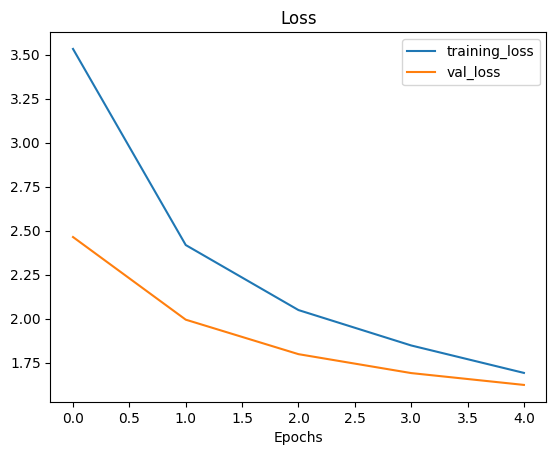

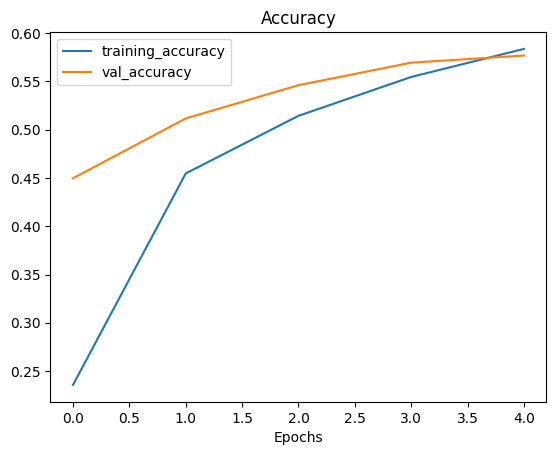

In [20]:
# Plotting Loss and Accuracy Curves:
plot_loss_curves(history= history_all_classes_10_percent)

Ideally, the two curves should be very similar to each other, if not, there may be some overfitting or underfitting.